# Conditional (Temporal) RBM — Plankton Time Series

A **Conditional RBM** (cRBM; Taylor et al. 2006) extends the standard RBM by adding autoregressive connections from the previous time step's visible units. This modifies the hidden and visible biases dynamically, so the model learns *transitions* between community states rather than treating each day as independent.

**Architecture (Gaussian-visible, Bernoulli-hidden):**
```
v_{t-1}  →  A  →  b_h_dynamic  ─┐
                                  ├── hidden h_t
v_t      →  W  ──────────────────┘

v_{t-1}  →  B  →  b_v_dynamic  ─┐
                                  ├── visible v_t (Gaussian)
h_t      →  W.T ────────────────┘
```

In [2]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import expit as sigmoid
import warnings
warnings.filterwarnings('ignore')
rng = np.random.default_rng(42)

In [3]:
# ── Load & preprocess ─────────────────────────────────────────────────────────
df = pd.read_csv('TimeSeries_countsuL_clean.csv', index_col=0, parse_dates=True)
df = df.dropna(how='all').fillna(0)

# ── Filter 1: prevalence — drop species absent on > 95% of days ───────────────
MIN_PREVALENCE = 0.05
presence       = (df > 0).mean(axis=0)
keep_prev      = presence >= MIN_PREVALENCE

# ── Filter 2: variance — log-transform first, then check std ──────────────────
# A species always present at ~constant density has log-std ≈ 0 after transform
# and conveys no correlational information.
eps_all   = df[df > 0].min().min() * 0.1
X_all_log = np.log10(df.values + eps_all)
log_std   = X_all_log.std(axis=0)

MIN_LOG_STD = 0.5    # ~half an order of magnitude variation in log10 space
keep_var    = log_std >= MIN_LOG_STD

keep = keep_prev & keep_var
print(f'Total species       : {len(df.columns)}')
print(f'Low prevalence (<{MIN_PREVALENCE*100:.0f}%): {(~keep_prev).sum()} dropped')
print(f'Low log-variance    : {(keep_prev & ~keep_var).sum()} dropped')
print(f'Remaining           : {keep.sum()}')

df      = df.loc[:, keep]
species = df.columns.tolist()

# ── Log-transform + standardise retained species ──────────────────────────────
eps   = df[df > 0].min().min() * 0.1
X_raw = np.log10(df.values + eps).astype(np.float32)

mu  = X_raw.mean(0, keepdims=True)
sig = X_raw.std(0, keepdims=True) + 1e-8
X   = (X_raw - mu) / sig

T, n_vis = X.shape
dates    = df.index

# ── 80/20 chronological train / validation split ──────────────────────────────
split   = int(0.8 * T)
X_train = X[:split]
X_val   = X[split:]
T_train = len(X_train)

print(f'\nData shape : {X.shape}  ({T} days, {n_vis} species)')
print(f'Train      : {T_train} days  ({dates[0].date()} → {dates[split-1].date()})')
print(f'Validation : {len(X_val)} days  ({dates[split].date()} → {dates[-1].date()})')

# ── Validation MSE helper ─────────────────────────────────────────────────────
def compute_val_mse(model, X_v):
    """One-step-ahead reconstruction MSE on a held-out sequence."""
    errs = []
    for t in range(1, len(X_v)):
        hp    = model.h_given_v(X_v[t], X_v[t-1])
        v_rec = model.v_given_h(hp, X_v[t-1])
        errs.append(float(np.mean((X_v[t] - v_rec) ** 2)))
    return float(np.mean(errs))

Total species       : 83
Low prevalence (<5%): 2 dropped
Low log-variance    : 0 dropped
Remaining           : 81

Data shape : (2066, 81)  (2066 days, 81 species)
Train      : 1652 days  (2019-03-26 → 2023-11-11)
Validation : 414 days  (2023-11-12 → 2024-12-31)


In [5]:
class ConditionalRBM:
    """
    Gaussian-visible / Bernoulli-hidden Conditional RBM.
    Autoregressive order = 1 (conditions on previous time step only).
    Trained with Contrastive Divergence k=1 (CD-1).
    """

    def __init__(self, n_visible, n_hidden, lr=1e-3, momentum=0.9, l2=1e-4):
        self.nv, self.nh = n_visible, n_hidden
        self.lr, self.mom, self.l2 = lr, momentum, l2

        # RBM weights + biases
        self.W  = rng.normal(0, 0.01, (n_hidden, n_visible)).astype(np.float32)
        self.bh = np.zeros(n_hidden,  dtype=np.float32)
        self.bv = np.zeros(n_visible, dtype=np.float32)

        # Autoregressive weights  (past visible → dynamic biases)
        self.A  = rng.normal(0, 0.01, (n_hidden,  n_visible)).astype(np.float32)  # → hidden bias
        self.B  = rng.normal(0, 0.01, (n_visible, n_visible)).astype(np.float32)  # → visible bias

        # Momentum buffers
        self._dW = np.zeros_like(self.W)
        self._dbh = np.zeros_like(self.bh)
        self._dbv = np.zeros_like(self.bv)
        self._dA  = np.zeros_like(self.A)
        self._dB  = np.zeros_like(self.B)

    # ── Conditional distributions ─────────────────────────────────────────────
    def _bh_dyn(self, v_prev):  return self.bh + self.A @ v_prev
    def _bv_dyn(self, v_prev):  return self.bv + self.B @ v_prev

    def h_given_v(self, v, v_prev):
        """P(h=1 | v_t, v_{t-1})  — shape (n_hidden,)"""
        return sigmoid(self.W @ v + self._bh_dyn(v_prev))

    def v_given_h(self, h, v_prev):
        """Mean of P(v_t | h_t, v_{t-1}) — Gaussian mean"""
        return self.W.T @ h + self._bv_dyn(v_prev)

    # ── CD-1 step ─────────────────────────────────────────────────────────────
    def cd1_step(self, v, v_prev):
        # Positive phase
        hp = self.h_given_v(v, v_prev)
        hs = (rng.random(self.nh) < hp).astype(np.float32)   # sample

        # Negative phase (Gibbs step)
        v_neg = self.v_given_h(hs, v_prev)                    # Gaussian mean
        hn    = self.h_given_v(v_neg, v_prev)

        # Gradients
        dW  = np.outer(hp, v) - np.outer(hn, v_neg)
        dbh = hp - hn
        dbv = v  - v_neg
        dA  = np.outer(hp - hn, v_prev)
        dB  = np.outer(v  - v_neg, v_prev)

        # Momentum + L2
        lr = self.lr
        self._dW  = self.mom * self._dW  + lr * (dW  - self.l2 * self.W)
        self._dbh = self.mom * self._dbh + lr * dbh
        self._dbv = self.mom * self._dbv + lr * dbv
        self._dA  = self.mom * self._dA  + lr * (dA  - self.l2 * self.A)
        self._dB  = self.mom * self._dB  + lr * (dB  - self.l2 * self.B)

        self.W  += self._dW;  self.bh += self._dbh
        self.bv += self._dbv; self.A  += self._dA;  self.B += self._dB

        return float(np.mean((v - v_neg) ** 2))   # reconstruction MSE

    # ── Encode full sequence → hidden activations ─────────────────────────────
    def encode(self, X):
        H = np.zeros((len(X) - 1, self.nh), dtype=np.float32)
        for t in range(1, len(X)):
            H[t-1] = self.h_given_v(X[t], X[t-1])
        return H

    # ── Reconstruct sequence ──────────────────────────────────────────────────
    def reconstruct(self, X):
        V_rec = np.zeros_like(X[1:])
        for t in range(1, len(X)):
            hp     = self.h_given_v(X[t], X[t-1])
            V_rec[t-1] = self.v_given_h(hp, X[t-1])
        return V_rec

In [7]:
# ── Single-model training (train on X_train, early-stop on val MSE) ───────────
N_HIDDEN   = 130
N_EPOCHS   = 1000
LR         = 5e-4
PATIENCE   = 100
BATCH_SIZE = 32

crbm = ConditionalRBM(n_vis, N_HIDDEN, lr=LR, momentum=0.9, l2=1e-4)

train_history = []
val_history   = []
best_val_mse  = np.inf
best_snap     = None
no_improve    = 0

for epoch in range(N_EPOCHS):
    # ── Mini-batch training on X_train ────────────────────────────────────────
    mse_epoch = []
    idx = rng.permutation(np.arange(1, T_train))

    for batch_start in range(0, len(idx), BATCH_SIZE):
        batch = idx[batch_start : batch_start + BATCH_SIZE]
        dW  = np.zeros_like(crbm.W);  dbh = np.zeros_like(crbm.bh)
        dbv = np.zeros_like(crbm.bv); dA  = np.zeros_like(crbm.A); dB = np.zeros_like(crbm.B)
        b_mse = []

        for t in batch:
            v, vp = X_train[t], X_train[t-1]
            hp  = crbm.h_given_v(v, vp)
            hs  = (rng.random(crbm.nh) < hp).astype(np.float32)
            v_n = crbm.v_given_h(hs, vp)                   # sampled  — used for gradient only
            hn  = crbm.h_given_v(v_n, vp)
            dW  += np.outer(hp, v)   - np.outer(hn, v_n)
            dbh += hp - hn;  dbv += v - v_n
            dA  += np.outer(hp - hn, vp);  dB += np.outer(v - v_n, vp)
            v_mf = crbm.v_given_h(hp, vp)                  # mean-field — used for MSE logging
            b_mse.append(float(np.mean((v - v_mf) ** 2)))

        n = len(batch); lr = crbm.lr
        crbm._dW  = crbm.mom*crbm._dW  + lr*(dW/n  - crbm.l2*crbm.W)
        crbm._dbh = crbm.mom*crbm._dbh + lr*(dbh/n)
        crbm._dbv = crbm.mom*crbm._dbv + lr*(dbv/n)
        crbm._dA  = crbm.mom*crbm._dA  + lr*(dA/n  - crbm.l2*crbm.A)
        crbm._dB  = crbm.mom*crbm._dB  + lr*(dB/n  - crbm.l2*crbm.B)
        crbm.W  += crbm._dW;  crbm.bh += crbm._dbh
        crbm.bv += crbm._dbv; crbm.A  += crbm._dA;  crbm.B += crbm._dB
        mse_epoch.extend(b_mse)

    train_history.append(float(np.mean(mse_epoch)))

    # ── Validation MSE (early-stopping criterion) ─────────────────────────────
    v_mse = compute_val_mse(crbm, X_val)
    val_history.append(v_mse)

    if v_mse < best_val_mse:
        best_val_mse = v_mse
        best_snap    = copy.deepcopy(crbm)
        no_improve   = 0
    else:
        no_improve  += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:4d}  |  train MSE = {train_history[-1]:.4f}'
              f'  |  val MSE = {v_mse:.4f}'
              f'  |  best val = {best_val_mse:.4f}'
              f'  |  patience = {no_improve}/{PATIENCE}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

# Restore best weights
crbm = best_snap
best_mse = best_val_mse
print(f'\nBest val MSE = {best_val_mse:.4f}  (R² ≈ {1 - best_val_mse:.2f})')

# ── Save model ────────────────────────────────────────────────────────────────
np.savez('crbm_model.npz',
         W=crbm.W, bh=crbm.bh, bv=crbm.bv, A=crbm.A, B=crbm.B,
         mu=mu, sig=sig,
         species=np.array(species),
         val_mse=np.array(best_val_mse),
         n_hidden=np.array(N_HIDDEN))
print(f'Model saved → crbm_model.npz')

Epoch   10  |  train MSE = 0.3647  |  val MSE = 0.5247  |  best val = 0.5247  |  patience = 0/100
Epoch   20  |  train MSE = 0.3416  |  val MSE = 0.5052  |  best val = 0.5052  |  patience = 0/100
Epoch   30  |  train MSE = 0.3222  |  val MSE = 0.4878  |  best val = 0.4878  |  patience = 0/100
Epoch   40  |  train MSE = 0.3037  |  val MSE = 0.4659  |  best val = 0.4659  |  patience = 0/100
Epoch   50  |  train MSE = 0.2825  |  val MSE = 0.4426  |  best val = 0.4426  |  patience = 0/100
Epoch   60  |  train MSE = 0.2606  |  val MSE = 0.4144  |  best val = 0.4144  |  patience = 0/100
Epoch   70  |  train MSE = 0.2412  |  val MSE = 0.3903  |  best val = 0.3903  |  patience = 0/100
Epoch   80  |  train MSE = 0.2252  |  val MSE = 0.3697  |  best val = 0.3697  |  patience = 0/100
Epoch   90  |  train MSE = 0.2122  |  val MSE = 0.3518  |  best val = 0.3518  |  patience = 0/100
Epoch  100  |  train MSE = 0.2018  |  val MSE = 0.3376  |  best val = 0.3372  |  patience = 1/100
Epoch  110  |  train

  N_hidden =  80  |  val MSE = 0.2535  |  train MSE = 0.1423  |  patience = 400  |  stopped @ epoch 1000

Best N_hidden = 80  (val MSE = 0.2535,  R² ≈ 0.75)


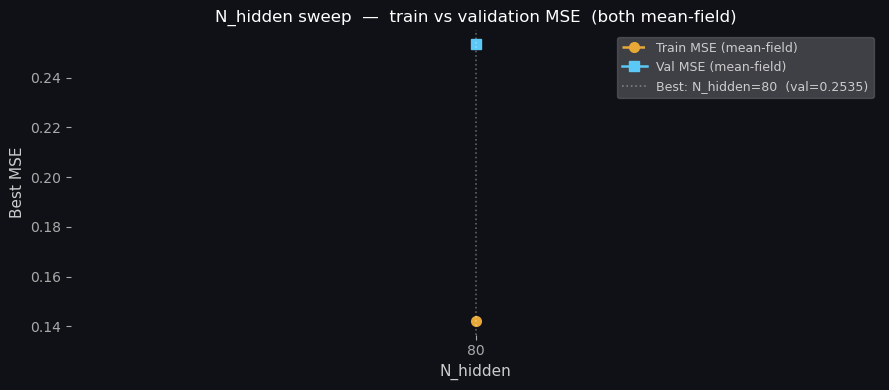

In [ ]:
# ── N_HIDDEN sweep (val MSE for selection, patience scaled by model size) ──────
import copy

SWEEP_HIDDEN = [80]
SWEEP_EPOCHS = 1000
SWEEP_BATCH  = 32

sweep_train_mse = {}
sweep_val_mse   = {}
sweep_models    = {}

for nh in SWEEP_HIDDEN:
    patience_nh = max(50, nh * 5)
    m           = ConditionalRBM(n_vis, nh, lr=LR, momentum=0.9, l2=1e-4)
    best_v      = np.inf
    best_t      = np.inf
    no_imp      = 0
    best_m      = None

    for epoch in range(SWEEP_EPOCHS):
        mse_ep = []
        idx    = rng.permutation(np.arange(1, T_train))

        for batch_start in range(0, len(idx), SWEEP_BATCH):
            batch = idx[batch_start : batch_start + SWEEP_BATCH]
            dW  = np.zeros_like(m.W);  dbh = np.zeros_like(m.bh)
            dbv = np.zeros_like(m.bv); dA  = np.zeros_like(m.A); dB = np.zeros_like(m.B)
            b_mse = []

            for t in batch:
                v, vp = X_train[t], X_train[t-1]
                hp  = m.h_given_v(v, vp)
                hs  = (rng.random(m.nh) < hp).astype(np.float32)
                v_n = m.v_given_h(hs, vp)                  # sampled  — gradient only
                hn  = m.h_given_v(v_n, vp)
                dW  += np.outer(hp, v)   - np.outer(hn, v_n)
                dbh += hp - hn;  dbv += v - v_n
                dA  += np.outer(hp - hn, vp);  dB += np.outer(v - v_n, vp)
                v_mf = m.v_given_h(hp, vp)                 # mean-field — MSE logging
                b_mse.append(float(np.mean((v - v_mf) ** 2)))

            n = len(batch); lr = m.lr
            m._dW  = m.mom*m._dW  + lr*(dW/n  - m.l2*m.W)
            m._dbh = m.mom*m._dbh + lr*(dbh/n)
            m._dbv = m.mom*m._dbv + lr*(dbv/n)
            m._dA  = m.mom*m._dA  + lr*(dA/n  - m.l2*m.A)
            m._dB  = m.mom*m._dB  + lr*(dB/n  - m.l2*m.B)
            m.W  += m._dW;  m.bh += m._dbh
            m.bv += m._dbv; m.A  += m._dA; m.B += m._dB
            mse_ep.extend(b_mse)

        ep_train = float(np.mean(mse_ep))
        ep_val   = compute_val_mse(m, X_val)

        if ep_val < best_v:
            best_v = ep_val
            best_t = ep_train
            no_imp = 0
            best_m = copy.deepcopy(m)
        else:
            no_imp += 1
        if no_imp >= patience_nh:
            break

    sweep_train_mse[nh] = best_t
    sweep_val_mse[nh]   = best_v
    sweep_models[nh]    = best_m
    print(f'  N_hidden = {nh:3d}  |  val MSE = {best_v:.4f}'
          f'  |  train MSE = {best_t:.4f}'
          f'  |  patience = {patience_nh}'
          f'  |  stopped @ epoch {epoch+1}')

# ── Pick best by validation MSE ────────────────────────────────────────────────
best_nh  = min(sweep_val_mse, key=sweep_val_mse.get)
best_mse = sweep_val_mse[best_nh]
crbm     = sweep_models[best_nh]
N_HIDDEN = best_nh
print(f'\nBest N_hidden = {best_nh}  (val MSE = {best_mse:.4f},  R² ≈ {1-best_mse:.2f})')

# ── Plot train vs val MSE across sweep ────────────────────────────────────────
nh_vals = list(sweep_val_mse.keys())
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(nh_vals, [sweep_train_mse[k] for k in nh_vals],
        'o--', color='#e8a838', linewidth=1.8, markersize=7, label='Train MSE (mean-field)')
ax.plot(nh_vals, [sweep_val_mse[k]   for k in nh_vals],
        's-',  color='#5bc8f5', linewidth=1.8, markersize=7, label='Val MSE (mean-field)')
ax.axvline(best_nh, color='#ffffff55', linestyle=':', linewidth=1.2,
           label=f'Best: N_hidden={best_nh}  (val={best_mse:.4f})')
ax.set_xlabel('N_hidden', color='#cccccc', fontsize=11)
ax.set_ylabel('Best MSE', color='#cccccc', fontsize=11)
ax.set_title('N_hidden sweep  —  train vs validation MSE  (both mean-field)', color='white', fontsize=12)
ax.tick_params(colors='#aaaaaa'); ax.set_xticks(nh_vals)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='#cccccc')
[s.set_visible(False) for s in ax.spines.values()]
plt.tight_layout()
plt.savefig('crbm_sweep.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
#val MSE = 0.2227 200
#val MSE = 0.2233 150
#val MSE = 0.2257 130
#val MSE = 0.2380 100



In [6]:
# ── Encode sequence + reconstruct ─────────────────────────────────────────────
H     = crbm.encode(X)       # (T-1, N_HIDDEN)  — latent community trajectory
V_rec = crbm.reconstruct(X)  # (T-1, n_vis)     — reconstructed densities

dates_enc = dates[1:]         # dates align with encoded steps

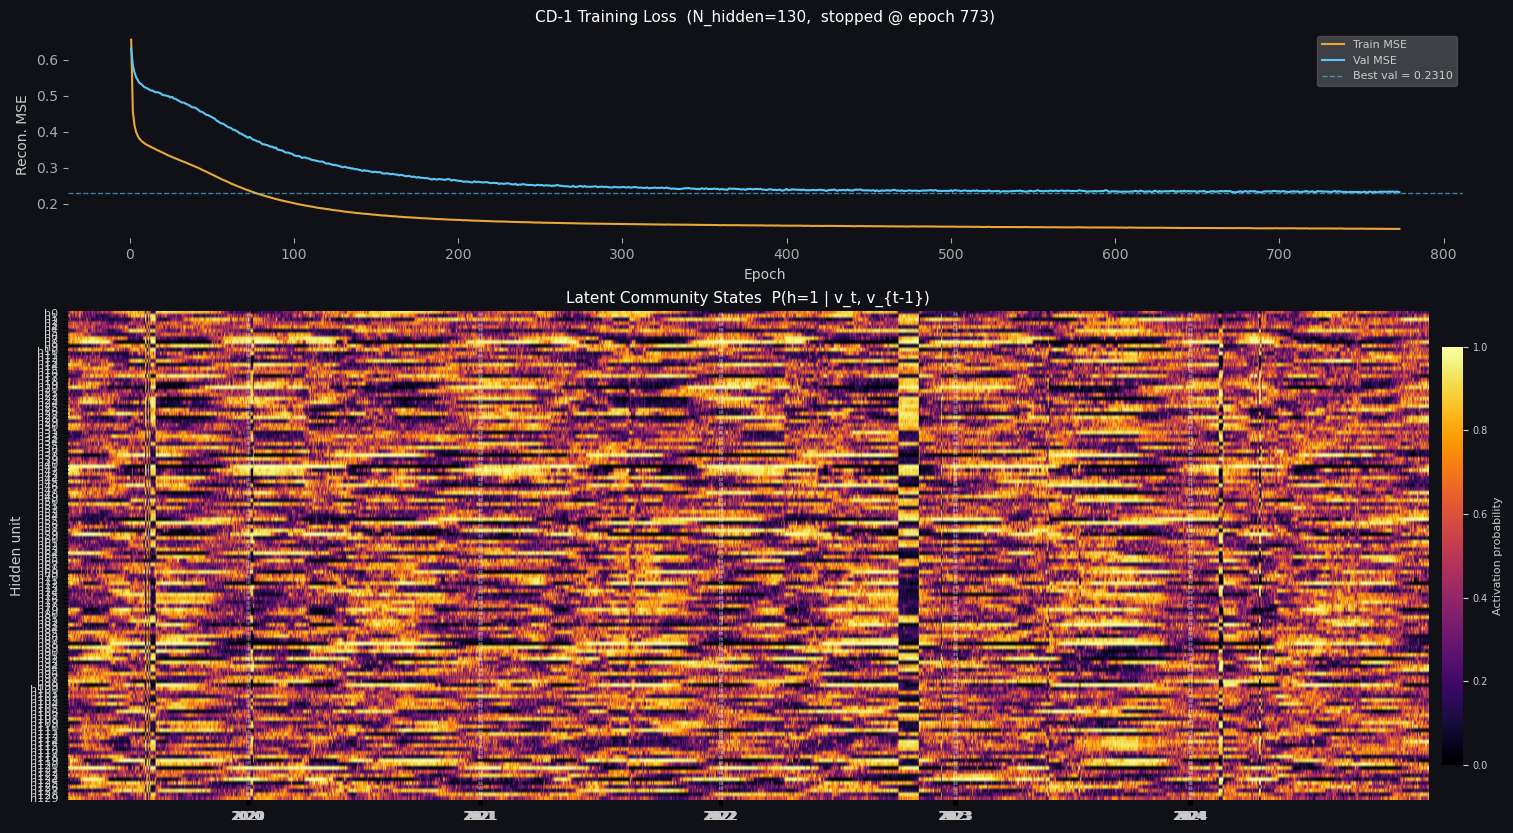

In [7]:
# ── Figure 1: Training curve + hidden unit activations over time ───────────────
n_epochs_run = len(train_history)

fig = plt.figure(figsize=(18, 10), facecolor='#0f1117')
gs  = gridspec.GridSpec(3, 1, hspace=0.35)

# -- Train vs validation loss -------------------------------------------------
ax0 = fig.add_subplot(gs[0])
ax0.set_facecolor('#0f1117')
epochs_x = range(1, n_epochs_run + 1)
ax0.plot(epochs_x, train_history, color='#e8a838', linewidth=1.5, label='Train MSE')
ax0.plot(epochs_x, val_history,   color='#5bc8f5', linewidth=1.5, label='Val MSE')
ax0.axhline(best_val_mse, color='#5bc8f5', linewidth=1, linestyle='--', alpha=0.6,
            label=f'Best val = {best_val_mse:.4f}')
ax0.legend(fontsize=8, framealpha=0.2, labelcolor='#cccccc')
ax0.set_xlabel('Epoch', color='#cccccc')
ax0.set_ylabel('Recon. MSE', color='#cccccc')
ax0.set_title(f'CD-1 Training Loss  (N_hidden={N_HIDDEN},  stopped @ epoch {n_epochs_run})',
              color='white', fontsize=11)
ax0.tick_params(colors='#aaaaaa')
[s.set_visible(False) for s in ax0.spines.values()]

# -- Hidden activations heatmap -----------------------------------------------
ax1 = fig.add_subplot(gs[1:3])
ax1.set_facecolor('#0f1117')
im = ax1.imshow(H.T, aspect='auto', cmap='inferno', vmin=0, vmax=1,
                extent=[0, len(dates_enc), N_HIDDEN, 0])

jan_pos = [i for i, d in enumerate(dates_enc) if d.month == 1 and d.day <= 7]
jan_lbl = [str(dates_enc[i].year) for i in jan_pos]
ax1.set_xticks(jan_pos); ax1.set_xticklabels(jan_lbl, color='#cccccc', fontsize=9)
for xi in jan_pos:
    ax1.axvline(xi, color='#ffffff33', linewidth=0.7, linestyle='--')

ax1.set_yticks(np.arange(N_HIDDEN) + 0.5)
ax1.set_yticklabels([f'h{i}' for i in range(N_HIDDEN)], color='#cccccc', fontsize=8)
ax1.set_ylabel('Hidden unit', color='#cccccc', fontsize=10)
ax1.set_title('Latent Community States  P(h=1 | v_t, v_{t-1})', color='white', fontsize=11)
[s.set_visible(False) for s in ax1.spines.values()]

cb = fig.colorbar(im, ax=ax1, fraction=0.015, pad=0.01)
cb.set_label('Activation probability', color='#cccccc', fontsize=8)
cb.ax.yaxis.set_tick_params(color='#cccccc', labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
cb.outline.set_visible(False)

plt.savefig('crbm_hidden_activations.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

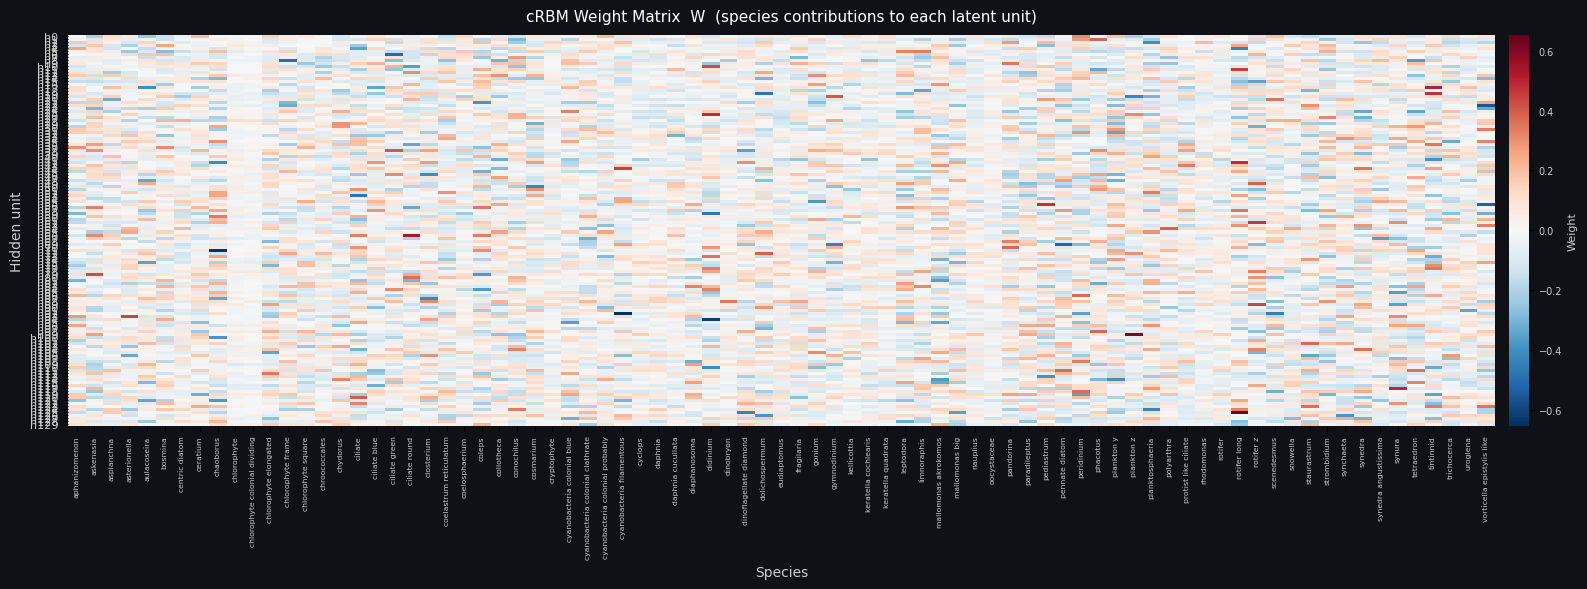

In [8]:
# ── Figure 2: Weight matrix — which species drive each hidden unit ─────────────
fig, ax = plt.subplots(figsize=(16, 6), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

vmax = np.abs(crbm.W).max()
im = ax.imshow(crbm.W, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(n_vis))
ax.set_xticklabels([s.replace('_', ' ') for s in species],
                   rotation=90, fontsize=5.5, color='#cccccc')
ax.set_yticks(range(N_HIDDEN))
ax.set_yticklabels([f'h{i}' for i in range(N_HIDDEN)], fontsize=8, color='#cccccc')
ax.set_xlabel('Species', color='#cccccc', fontsize=10)
ax.set_ylabel('Hidden unit', color='#cccccc', fontsize=10)
ax.set_title('cRBM Weight Matrix  W  (species contributions to each latent unit)',
             color='white', fontsize=11, pad=10)
[s.set_visible(False) for s in ax.spines.values()]

cb = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cb.set_label('Weight', color='#cccccc', fontsize=8)
cb.ax.yaxis.set_tick_params(labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
cb.outline.set_visible(False)

plt.tight_layout()
plt.savefig('crbm_weights.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

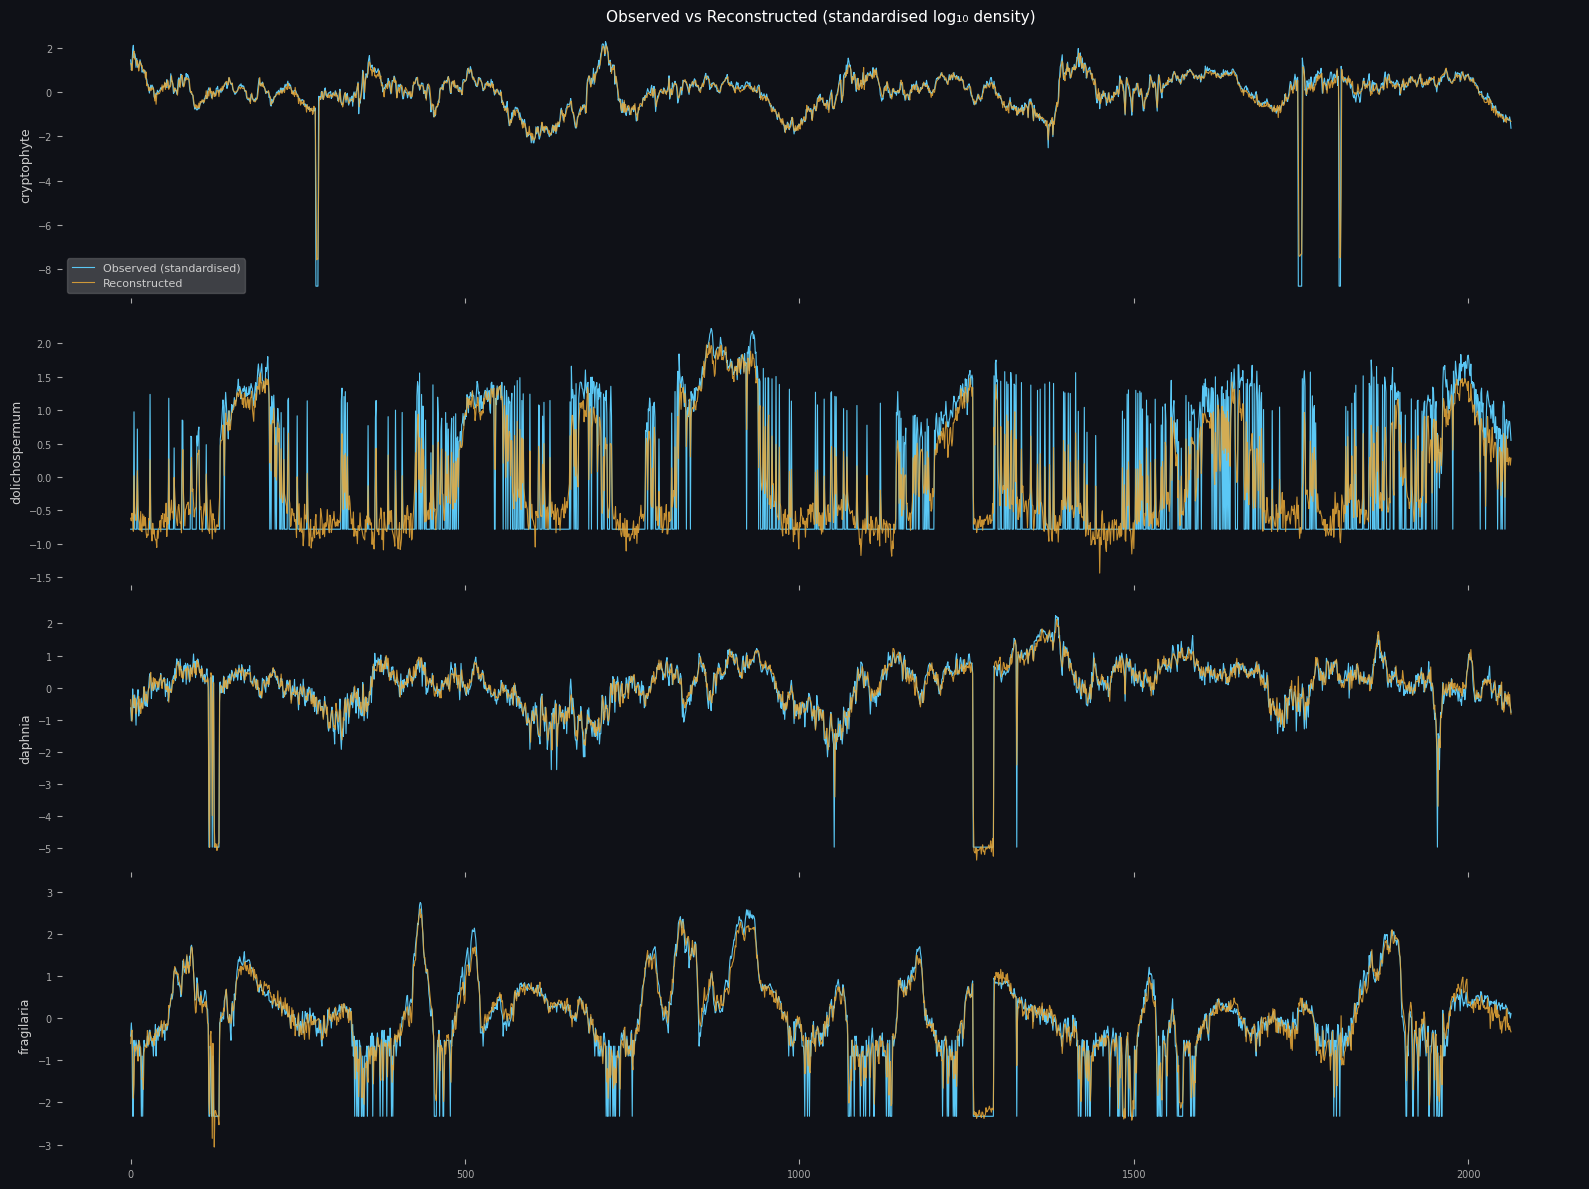

In [9]:
# ── Figure 3: Reconstruction quality for a few species ────────────────────────
# Pick 4 ecologically interesting taxa to compare
check_species = ['cryptophyte', 'dolichospermum', 'daphnia', 'fragilaria']
check_species = [s for s in check_species if s in species]   # guard against missing

fig, axes = plt.subplots(len(check_species), 1, figsize=(16, 3*len(check_species)),
                         sharex=True, facecolor='#0f1117')

for ax, sp in zip(axes, check_species):
    ax.set_facecolor('#0f1117')
    idx = species.index(sp)
    obs = X[1:, idx]
    rec = V_rec[:, idx]
    ax.plot(obs, color='#5bc8f5', linewidth=0.8, label='Observed (standardised)')
    ax.plot(rec, color='#e8a838', linewidth=0.8, alpha=0.85, label='Reconstructed')
    ax.set_ylabel(sp.replace('_',' '), color='#cccccc', fontsize=9)
    ax.tick_params(colors='#aaaaaa', labelsize=7)
    [s.set_visible(False) for s in ax.spines.values()]
    if ax == axes[0]:
        ax.legend(fontsize=8, framealpha=0.2, labelcolor='#cccccc')
        ax.set_title('Observed vs Reconstructed (standardised log₁₀ density)',
                     color='white', fontsize=11)

plt.tight_layout()
plt.savefig('crbm_reconstruction.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## Interpreting the outputs

| Output | Shape | Ecological meaning |
|---|---|---|
| `H` (hidden activations) | `(T-1, 15)` | Daily probability of each latent community state being active — the compressed trajectory of community dynamics |
| `crbm.W` (weight matrix) | `(15, 82)` | Which species positively/negatively define each hidden unit |
| `crbm.A` (AR→hidden) | `(15, 82)` | How yesterday's community composition biases today's latent states — encodes transition rules |
| `crbm.B` (AR→visible) | `(82, 82)` | Direct species-to-species temporal carry-over effects |

**Next steps:**
- Vary `N_HIDDEN` (try 5–30) and compare reconstruction MSE
- Cluster hidden activation patterns to find recurring community regimes
- Use `H` as features for downstream prediction (e.g. bloom forecasting)

Silhouette-optimal K = 2  |  Using K = 4


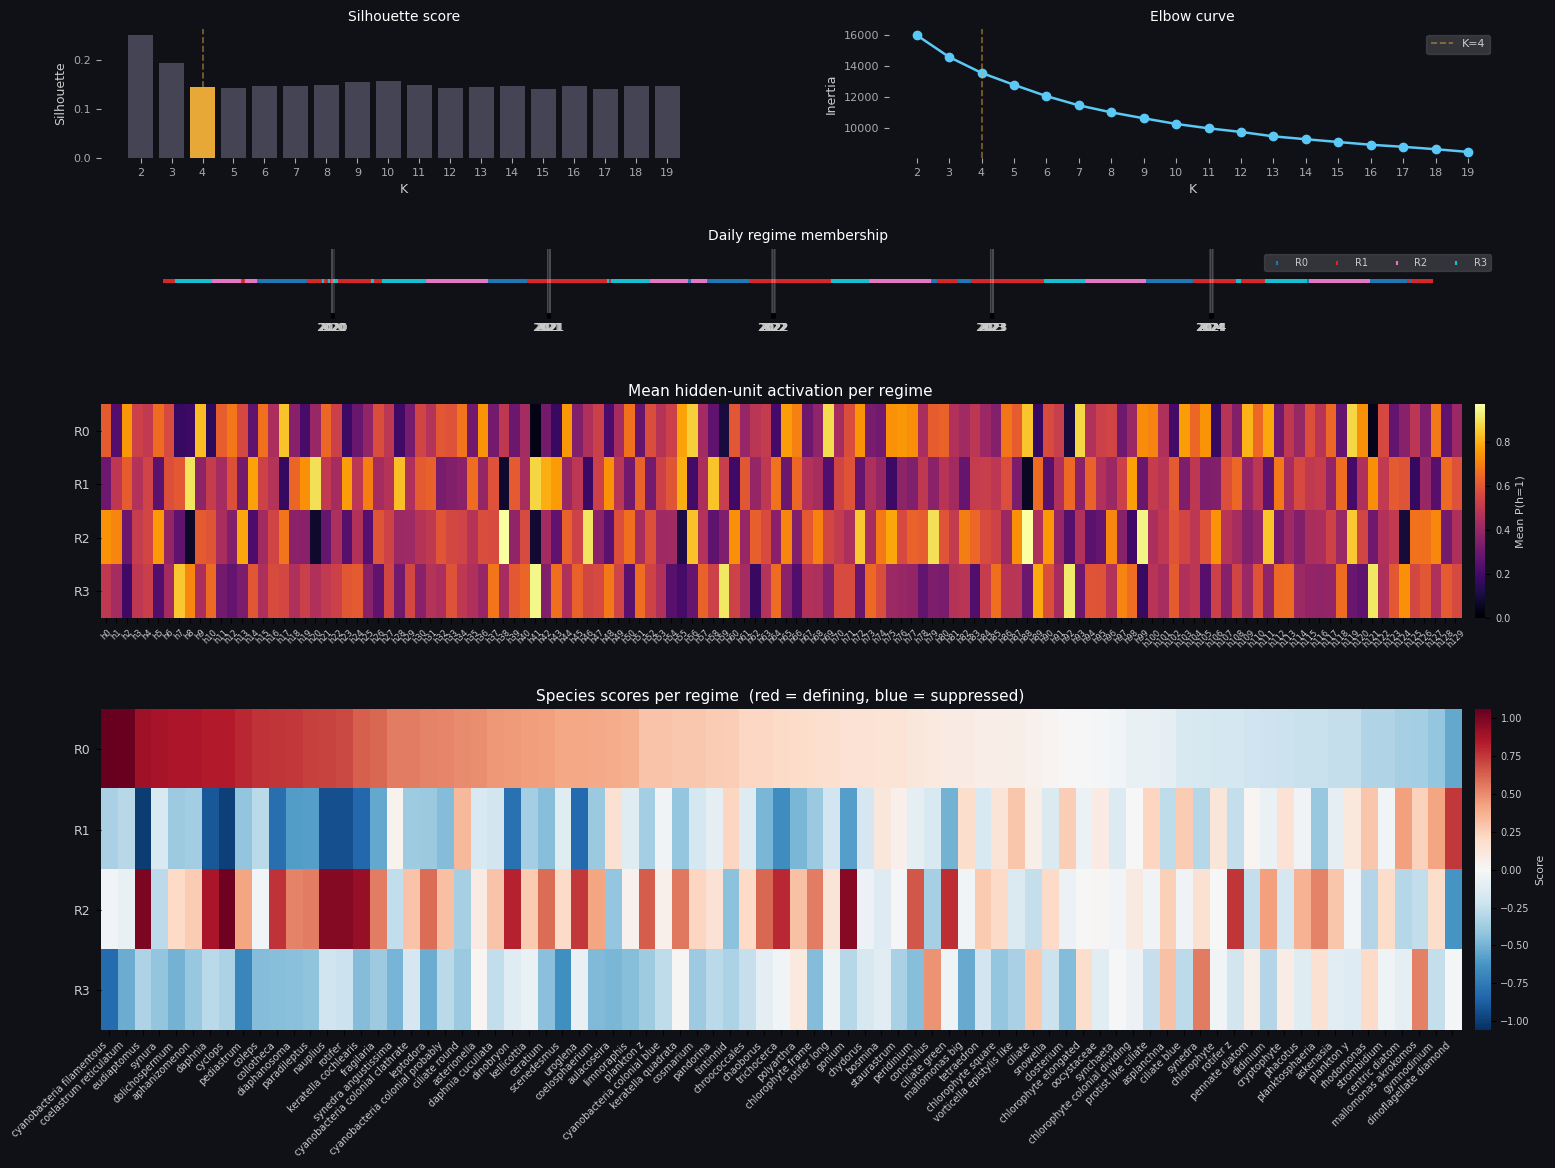


Regime     Days   % total  Top species
──────────────────────────────────────────────────────────────────────
  R0        441     21.4%  cyanobacteria filamentous, coelastrum reticulatum, eudiaptomus
  R1        706     34.2%  dinoflagellate diamond, centric diatom, gymnodinium
  R2        542     26.2%  cyclops, eudiaptomus, nauplius
  R3        376     18.2%  synedra, mallomonas akrokomos, conochilus


In [19]:
# ── Figure 4: Community regime clustering ─────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Set K here (None = pick automatically via silhouette) ─────────────────────
K_OVERRIDE = 4    # set to None to use silhouette-optimal K

# ── 1. Silhouette + inertia across K range ─────────────────────────────────────
K_RANGE    = range(2, 20)
sil_scores = []
inertias   = []
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(H)
    sil_scores.append(silhouette_score(H, lbl))
    inertias.append(km.inertia_)

auto_K = list(K_RANGE)[int(np.argmax(sil_scores))]
best_K = K_OVERRIDE if K_OVERRIDE is not None else auto_K
print(f'Silhouette-optimal K = {auto_K}  |  Using K = {best_K}')

km_best = KMeans(n_clusters=best_K, random_state=42, n_init=20)
regime  = km_best.fit_predict(H)
PAL     = plt.cm.tab10(np.linspace(0, 0.9, best_K))

# ── 2. Per-regime summaries ────────────────────────────────────────────────────
regime_H       = np.stack([H[regime == k].mean(0) for k in range(best_K)])
regime_species = regime_H @ crbm.W

# ── 3. Figure layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13), facecolor='#0f1117')
gs  = gridspec.GridSpec(4, 2, figure=fig,
                        height_ratios=[1.2, 0.6, 2, 3],
                        hspace=0.50, wspace=0.30)
BG = '#0f1117'

# ── Panel A: silhouette scores ─────────────────────────────────────────────────
ax_sil = fig.add_subplot(gs[0, 0])
ax_sil.set_facecolor(BG)
colours = ['#e8a838' if list(K_RANGE)[i] == best_K else '#444455'
           for i in range(len(list(K_RANGE)))]
ax_sil.bar(list(K_RANGE), sil_scores, color=colours, edgecolor='none')
ax_sil.axvline(best_K, color='#e8a83888', linestyle='--', linewidth=1.2)
ax_sil.set_xlabel('K', color='#cccccc', fontsize=9)
ax_sil.set_ylabel('Silhouette', color='#cccccc', fontsize=9)
ax_sil.set_title('Silhouette score', color='white', fontsize=10)
ax_sil.set_xticks(list(K_RANGE))
ax_sil.tick_params(colors='#aaaaaa', labelsize=8)
[s.set_visible(False) for s in ax_sil.spines.values()]

# ── Panel B: inertia (elbow) ───────────────────────────────────────────────────
ax_elb = fig.add_subplot(gs[0, 1])
ax_elb.set_facecolor(BG)
ax_elb.plot(list(K_RANGE), inertias, 'o-', color='#5bc8f5', linewidth=1.8, markersize=6)
ax_elb.axvline(best_K, color='#e8a83888', linestyle='--', linewidth=1.2,
               label=f'K={best_K}')
ax_elb.set_xlabel('K', color='#cccccc', fontsize=9)
ax_elb.set_ylabel('Inertia', color='#cccccc', fontsize=9)
ax_elb.set_title('Elbow curve', color='white', fontsize=10)
ax_elb.set_xticks(list(K_RANGE))
ax_elb.tick_params(colors='#aaaaaa', labelsize=8)
ax_elb.legend(fontsize=8, framealpha=0.15, labelcolor='#cccccc')
[s.set_visible(False) for s in ax_elb.spines.values()]

# ── Panel C: regime timeline ───────────────────────────────────────────────────
ax_tl = fig.add_subplot(gs[1, :])
ax_tl.set_facecolor(BG)
day_idx = np.arange(len(dates_enc))
for k in range(best_K):
    mask = regime == k
    ax_tl.scatter(day_idx[mask], np.zeros(mask.sum()),
                  c=[PAL[k]], s=5, marker='|', label=f'R{k}')
jan_pos = [i for i, d in enumerate(dates_enc) if d.month == 1 and d.day <= 7]
jan_lbl = [str(dates_enc[i].year) for i in jan_pos]
ax_tl.set_xticks(jan_pos)
ax_tl.set_xticklabels(jan_lbl, color='#cccccc', fontsize=8)
for xi in jan_pos:
    ax_tl.axvline(xi, color='#ffffff22', linewidth=0.7)
ax_tl.set_yticks([])
ax_tl.set_title('Daily regime membership', color='white', fontsize=10)
ax_tl.legend(fontsize=7, framealpha=0.15, labelcolor='#cccccc',
             loc='upper right', ncol=best_K)
[s.set_visible(False) for s in ax_tl.spines.values()]

# ── Panel D: mean hidden activation per regime ─────────────────────────────────
ax_h = fig.add_subplot(gs[2, :])
ax_h.set_facecolor(BG)
im_h = ax_h.imshow(regime_H, aspect='auto', cmap='inferno', vmin=0, vmax=regime_H.max())
ax_h.set_xticks(range(N_HIDDEN))
ax_h.set_xticklabels([f'h{i}' for i in range(N_HIDDEN)],
                     fontsize=6, color='#cccccc', rotation=45)
ax_h.set_yticks(range(best_K))
ax_h.set_yticklabels([f'R{k}' for k in range(best_K)], fontsize=9, color='#cccccc')
ax_h.set_title('Mean hidden-unit activation per regime', color='white', fontsize=11)
[s.set_visible(False) for s in ax_h.spines.values()]
cb_h = fig.colorbar(im_h, ax=ax_h, fraction=0.015, pad=0.01)
cb_h.set_label('Mean P(h=1)', color='#cccccc', fontsize=8)
cb_h.ax.yaxis.set_tick_params(labelsize=7)
plt.setp(cb_h.ax.yaxis.get_ticklabels(), color='#cccccc')
cb_h.outline.set_visible(False)

# ── Panel E: top species per regime ───────────────────────────────────────────
N_TOP  =82
ax_sp  = fig.add_subplot(gs[3, :])
ax_sp.set_facecolor(BG)
all_top = []
for k in range(best_K):
    scores = regime_species[k]
    all_top += np.argsort(scores)[-N_TOP:][::-1].tolist()
    all_top += np.argsort(scores)[:N_TOP].tolist()
top_idx = list(dict.fromkeys(all_top))
sub     = regime_species[:, top_idx]
vabs    = np.abs(sub).max()
im_sp   = ax_sp.imshow(sub, aspect='auto', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
ax_sp.set_xticks(range(len(top_idx)))
ax_sp.set_xticklabels([species[i].replace('_', ' ') for i in top_idx],
                       rotation=45, ha='right', fontsize=7, color='#cccccc')
ax_sp.set_yticks(range(best_K))
ax_sp.set_yticklabels([f'R{k}' for k in range(best_K)], fontsize=9, color='#cccccc')
ax_sp.set_title('Species scores per regime  (red = defining, blue = suppressed)',
                color='white', fontsize=11)
[s.set_visible(False) for s in ax_sp.spines.values()]
cb_sp = fig.colorbar(im_sp, ax=ax_sp, fraction=0.015, pad=0.01)
cb_sp.set_label('Score', color='#cccccc', fontsize=8)
cb_sp.ax.yaxis.set_tick_params(labelsize=7)
plt.setp(cb_sp.ax.yaxis.get_ticklabels(), color='#cccccc')
cb_sp.outline.set_visible(False)

plt.savefig('crbm_regimes.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ── 4. Text summary ────────────────────────────────────────────────────────────
print(f'\n{"Regime":<8}  {"Days":>5}  {"% total":>8}  Top species')
print('─' * 70)
for k in range(best_K):
    n_days = (regime == k).sum()
    scores = regime_species[k]
    top3   = [species[i].replace('_', ' ') for i in np.argsort(scores)[-3:][::-1]]
    print(f'  R{k:<5}  {n_days:>5}  {100*n_days/len(regime):>7.1f}%  {", ".join(top3)}')

Regime → dominant season:
  R0  Autumn  (21% of days)
  R1  Winter  (34% of days)
  R2  Summer  (26% of days)
  R3  Spring  (18% of days)


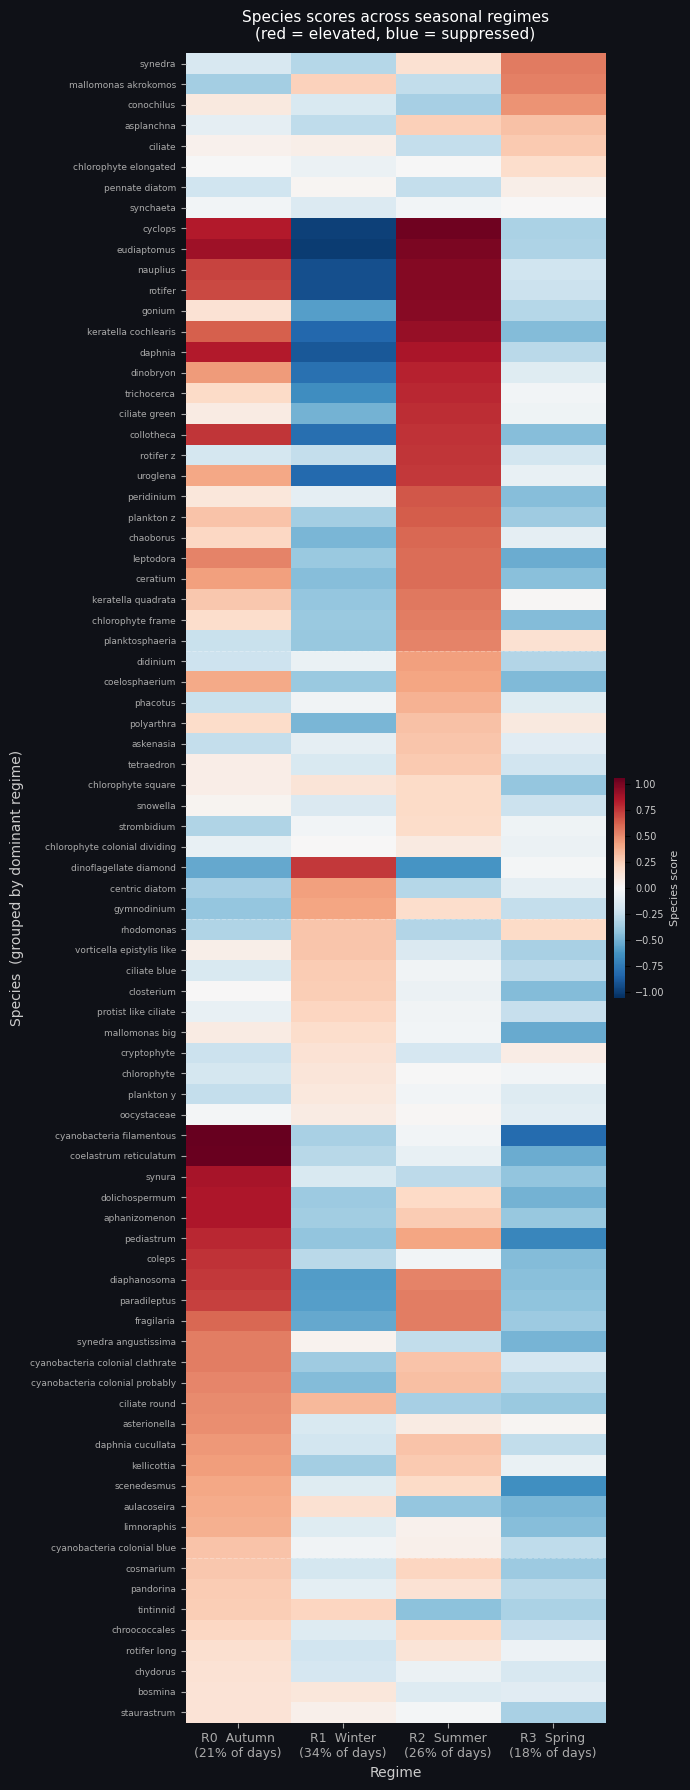

In [20]:
# ── Figure 5: All-species seasonal heatmap (K=4 regimes) ──────────────────────
from sklearn.cluster import KMeans

# ── 1. Cluster with K=4 ────────────────────────────────────────────────────────
K4      = 4
km4     = KMeans(n_clusters=K4, random_state=42, n_init=20)
reg4    = km4.fit_predict(H)                                  # (T-1,) regime per day
reg4_H  = np.stack([H[reg4 == k].mean(0) for k in range(K4)])
reg4_sp = reg4_H @ crbm.W                                     # (K4, n_vis)

# ── 2. Assign season labels from dominant month per regime ─────────────────────
months = np.array([d.month for d in dates_enc])
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
               3: 'Spring', 4: 'Spring', 5: 'Spring',
               6: 'Summer', 7: 'Summer', 8: 'Summer',
               9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}

regime_labels = []
for k in range(K4):
    mask        = reg4 == k
    dom_month   = int(np.bincount(months[mask]).argmax())
    dom_season  = season_map.get(dom_month, f'R{k}')
    pct         = 100 * mask.sum() / len(reg4)
    regime_labels.append(f'R{k}  {dom_season}\n({pct:.0f}% of days)')

print('Regime → dominant season:')
for k, lbl in enumerate(regime_labels):
    print(f'  {lbl.replace(chr(10), "  ")}')

# ── 3. Sort species by dominant regime then by score ───────────────────────────
dominant_regime = np.argmax(reg4_sp, axis=0)          # which regime each species peaks in
peak_score      = reg4_sp[dominant_regime, np.arange(n_vis)]
sort_idx        = np.lexsort((peak_score, dominant_regime))[::-1]

sorted_species  = [species[i].replace('_', ' ') for i in sort_idx]
sorted_scores   = reg4_sp[:, sort_idx]                # (K4, n_vis)

# ── 4. Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 18), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

vabs = np.abs(sorted_scores).max()
im   = ax.imshow(sorted_scores.T, aspect='auto', cmap='RdBu_r',
                 vmin=-vabs, vmax=vabs)

# x-axis: regimes / seasons
ax.set_xticks(range(K4))
ax.set_xticklabels(regime_labels, color='#cccccc', fontsize=9)

# y-axis: all species
ax.set_yticks(range(n_vis))
ax.set_yticklabels(sorted_species, fontsize=6.5, color='#cccccc')

# dividers between regime groups
boundaries = []
for k in range(K4 - 1):
    n_in_group = (dominant_regime[sort_idx] == k).sum()
    boundaries.append(n_in_group - 0.5 if not boundaries
                      else boundaries[-1] + n_in_group)
cumsum = 0
for k in range(K4 - 1):
    cumsum += (dominant_regime[sort_idx] == k).sum()
    ax.axhline(cumsum - 0.5, color='#ffffff44', linewidth=0.8, linestyle='--')

ax.set_title('Species scores across seasonal regimes\n(red = elevated, blue = suppressed)',
             color='white', fontsize=11, pad=10)
ax.set_xlabel('Regime', color='#cccccc', fontsize=10)
ax.set_ylabel('Species  (grouped by dominant regime)', color='#cccccc', fontsize=10)
ax.tick_params(colors='#aaaaaa')
[s.set_visible(False) for s in ax.spines.values()]

cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label('Species score', color='#cccccc', fontsize=8)
cb.ax.yaxis.set_tick_params(labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
cb.outline.set_visible(False)

plt.tight_layout()
plt.savefig('crbm_seasonal_species.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

RBM train: 1652 days  |  val: 414 days  (random split)
Epoch   50  |  train MSE = 0.3370  |  val MSE = 0.3395  |  best val = 0.3395  |  patience = 0/150
Epoch  100  |  train MSE = 0.2271  |  val MSE = 0.2350  |  best val = 0.2350  |  patience = 0/150
Epoch  150  |  train MSE = 0.1865  |  val MSE = 0.1944  |  best val = 0.1944  |  patience = 0/150
Epoch  200  |  train MSE = 0.1678  |  val MSE = 0.1759  |  best val = 0.1759  |  patience = 0/150
Epoch  250  |  train MSE = 0.1591  |  val MSE = 0.1668  |  best val = 0.1667  |  patience = 3/150
Epoch  300  |  train MSE = 0.1531  |  val MSE = 0.1615  |  best val = 0.1615  |  patience = 0/150
Epoch  350  |  train MSE = 0.1500  |  val MSE = 0.1585  |  best val = 0.1581  |  patience = 1/150
Epoch  400  |  train MSE = 0.1471  |  val MSE = 0.1564  |  best val = 0.1559  |  patience = 6/150
Epoch  450  |  train MSE = 0.1452  |  val MSE = 0.1544  |  best val = 0.1543  |  patience = 9/150
Epoch  500  |  train MSE = 0.1434  |  val MSE = 0.1532  |  best

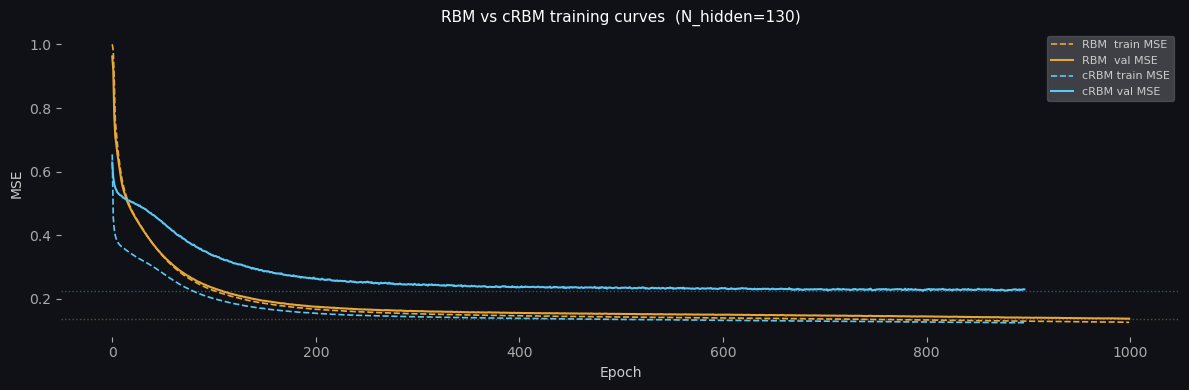

In [8]:
# ── Baseline: standard Gaussian-Bernoulli RBM (no temporal conditioning) ──────
#
# Differences from the cRBM:
#   • No autoregressive weights A or B
#   • h_given_v(v) and v_given_h(h) take no v_prev
#   • Each day is treated as an i.i.d. sample (order ignored during training)
#   • Random 80/20 split — correct for i.i.d. data (no temporal bias)
#   • Val MSE = reconstruction MSE  (not one-step-ahead prediction)
# ─────────────────────────────────────────────────────────────────────────────

class GaussianRBM:
    """Gaussian-visible / Bernoulli-hidden RBM.  No temporal connections."""

    def __init__(self, n_visible, n_hidden, lr=1e-3, momentum=0.9, l2=1e-4):
        self.nv, self.nh     = n_visible, n_hidden
        self.lr, self.mom, self.l2 = lr, momentum, l2
        self.W  = rng.normal(0, 0.01, (n_hidden, n_visible)).astype(np.float32)
        self.bh = np.zeros(n_hidden,  dtype=np.float32)
        self.bv = np.zeros(n_visible, dtype=np.float32)
        self._dW  = np.zeros_like(self.W)
        self._dbh = np.zeros_like(self.bh)
        self._dbv = np.zeros_like(self.bv)

    def h_given_v(self, v):
        return sigmoid(self.W @ v + self.bh)

    def v_given_h(self, h):
        return self.W.T @ h + self.bv

    def encode(self, X):
        return np.stack([self.h_given_v(X[t]) for t in range(len(X))])

# ── Random 80/20 split (i.i.d. — order does not matter) ──────────────────────
rbm_perm      = rng.permutation(T)
rbm_split     = int(0.8 * T)
rbm_train_idx = rbm_perm[:rbm_split]
rbm_val_idx   = rbm_perm[rbm_split:]
X_rbm_train   = X[rbm_train_idx]
X_rbm_val     = X[rbm_val_idx]
print(f'RBM train: {len(X_rbm_train)} days  |  val: {len(X_rbm_val)} days  (random split)')

# ── Training ──────────────────────────────────────────────────────────────────
RBM_HIDDEN   = N_HIDDEN    # same capacity as the cRBM for fair comparison
RBM_EPOCHS   = 1000
RBM_LR       = 5e-4
RBM_PATIENCE = 150
RBM_BATCH    = 32

rbm           = GaussianRBM(n_vis, RBM_HIDDEN, lr=RBM_LR, momentum=0.9, l2=1e-4)
rbm_train_his = []
rbm_val_his   = []
rbm_best_val  = np.inf
rbm_best_snap = None
rbm_no_imp    = 0

for epoch in range(RBM_EPOCHS):
    mse_epoch = []
    idx = rng.permutation(len(X_rbm_train))

    for batch_start in range(0, len(idx), RBM_BATCH):
        batch = idx[batch_start : batch_start + RBM_BATCH]
        dW  = np.zeros_like(rbm.W)
        dbh = np.zeros_like(rbm.bh)
        dbv = np.zeros_like(rbm.bv)
        b_mse = []

        for t in batch:
            v  = X_rbm_train[t]
            hp = rbm.h_given_v(v)
            hs = (rng.random(rbm.nh) < hp).astype(np.float32)   # CD-1 sample
            vn = rbm.v_given_h(hs)
            hn = rbm.h_given_v(vn)
            dW  += np.outer(hp, v) - np.outer(hn, vn)
            dbh += hp - hn
            dbv += v  - vn
            v_mf = rbm.v_given_h(hp)                             # mean-field recon
            b_mse.append(float(np.mean((v - v_mf) ** 2)))

        n = len(batch); lr = rbm.lr
        rbm._dW  = rbm.mom * rbm._dW  + lr * (dW/n  - rbm.l2 * rbm.W)
        rbm._dbh = rbm.mom * rbm._dbh + lr * (dbh/n)
        rbm._dbv = rbm.mom * rbm._dbv + lr * (dbv/n)
        rbm.W  += rbm._dW;  rbm.bh += rbm._dbh;  rbm.bv += rbm._dbv
        mse_epoch.extend(b_mse)

    rbm_train_his.append(float(np.mean(mse_epoch)))

    # ── Val reconstruction MSE ────────────────────────────────────────────────
    val_errs = [float(np.mean((X_rbm_val[t] - rbm.v_given_h(rbm.h_given_v(X_rbm_val[t]))) ** 2))
                for t in range(len(X_rbm_val))]
    v_mse = float(np.mean(val_errs))
    rbm_val_his.append(v_mse)

    if v_mse < rbm_best_val:
        rbm_best_val  = v_mse
        rbm_best_snap = copy.deepcopy(rbm)
        rbm_no_imp    = 0
    else:
        rbm_no_imp += 1

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:4d}  |  train MSE = {rbm_train_his[-1]:.4f}'
              f'  |  val MSE = {v_mse:.4f}'
              f'  |  best val = {rbm_best_val:.4f}'
              f'  |  patience = {rbm_no_imp}/{RBM_PATIENCE}')

    if rbm_no_imp >= RBM_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

rbm = rbm_best_snap
print(f'\nRBM  best val MSE = {rbm_best_val:.4f}  (R² ≈ {1 - rbm_best_val:.2f})')
print(f'cRBM best val MSE = {best_val_mse:.4f}  (R² ≈ {1 - best_val_mse:.2f})')
print(f'\nNote: RBM MSE = reconstruction (v→h→v);  cRBM MSE = prediction (v_{{t-1}},v_t→h→v_t)')

# ── Training curves comparison ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(rbm_train_his,  color='#e8a838', linewidth=1.2, linestyle='--', label='RBM  train MSE')
ax.plot(rbm_val_his,    color='#e8a838', linewidth=1.5, label='RBM  val MSE')
ax.plot(train_history,  color='#5bc8f5', linewidth=1.2, linestyle='--', label='cRBM train MSE')
ax.plot(val_history,    color='#5bc8f5', linewidth=1.5, label='cRBM val MSE')
ax.axhline(rbm_best_val,  color='#e8a83866', linewidth=1, linestyle=':')
ax.axhline(best_val_mse,  color='#5bc8f566', linewidth=1, linestyle=':')
ax.set_xlabel('Epoch', color='#cccccc', fontsize=10)
ax.set_ylabel('MSE', color='#cccccc', fontsize=10)
ax.set_title(f'RBM vs cRBM training curves  (N_hidden={RBM_HIDDEN})', color='white', fontsize=11)
ax.legend(fontsize=8, framealpha=0.2, labelcolor='#cccccc')
ax.tick_params(colors='#aaaaaa')
[s.set_visible(False) for s in ax.spines.values()]
plt.tight_layout()
plt.savefig('rbm_vs_crbm.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [ ]:
# ── RBM N_hidden adaptive sweep ───────────────────────────────────────────────
# Algorithm:
#   1. Evaluate coarse anchor points.
#   2. For every adjacent pair (lo, hi) in the results so far:
#      if the val MSE drop is SMALL (< MIN_IMPROVEMENT) AND the gap is still
#      wide enough, zoom in by inserting the midpoint into the queue.
#   3. Repeat until the queue is empty.
#
# Effect: dense sampling near the transition from "still improving" to "plateau",
#         sparse sampling in regions that are clearly still improving (no need to
#         pinpoint there — we just want the plateau).
# ─────────────────────────────────────────────────────────────────────────────

from collections import deque

MIN_IMPROVEMENT = 0.005   # val MSE drop below this → zoom into the interval
MIN_GAP         = 6        # don't refine intervals narrower than this
RBM_SW_EPOCHS   = 1000
RBM_SW_LR       = 5e-4
RBM_SW_BATCH    = 32

rbm_sw_val   = {}   # nh -> best val MSE
rbm_sw_train = {}   # nh -> best train MSE
rbm_sw_model = {}   # nh -> best model snapshot


def _train_rbm_nh(nh):
    """Train one GaussianRBM with `nh` hidden units; store result in dicts."""
    if nh in rbm_sw_val:
        return                                # already evaluated

    patience_nh = max(60, nh * 3)
    m           = GaussianRBM(n_vis, nh, lr=RBM_SW_LR, momentum=0.9, l2=1e-4)
    best_v = np.inf;  best_t = np.inf;  no_imp = 0;  best_m = None

    for epoch in range(RBM_SW_EPOCHS):
        mse_ep = []
        idx    = rng.permutation(len(X_rbm_train))

        for bs in range(0, len(idx), RBM_SW_BATCH):
            batch = idx[bs : bs + RBM_SW_BATCH]
            dW  = np.zeros_like(m.W)
            dbh = np.zeros_like(m.bh)
            dbv = np.zeros_like(m.bv)
            b_mse = []

            for t in batch:
                v  = X_rbm_train[t]
                hp = m.h_given_v(v)
                hs = (rng.random(m.nh) < hp).astype(np.float32)
                vn = m.v_given_h(hs)
                hn = m.h_given_v(vn)
                dW  += np.outer(hp, v) - np.outer(hn, vn)
                dbh += hp - hn
                dbv += v  - vn
                v_mf = m.v_given_h(hp)
                b_mse.append(float(np.mean((v - v_mf) ** 2)))

            n = len(batch); lr = m.lr
            m._dW  = m.mom * m._dW  + lr * (dW/n  - m.l2 * m.W)
            m._dbh = m.mom * m._dbh + lr * (dbh/n)
            m._dbv = m.mom * m._dbv + lr * (dbv/n)
            m.W  += m._dW;  m.bh += m._dbh;  m.bv += m._dbv
            mse_ep.extend(b_mse)

        ep_train = float(np.mean(mse_ep))
        ep_val   = float(np.mean([
            np.mean((X_rbm_val[t] - m.v_given_h(m.h_given_v(X_rbm_val[t]))) ** 2)
            for t in range(len(X_rbm_val))
        ]))

        if ep_val < best_v:
            best_v = ep_val;  best_t = ep_train;  no_imp = 0
            best_m = copy.deepcopy(m)
        else:
            no_imp += 1
        if no_imp >= patience_nh:
            break

    rbm_sw_val[nh]   = best_v
    rbm_sw_train[nh] = best_t
    rbm_sw_model[nh] = best_m
    print(f'  N_hidden = {nh:3d}  |  val MSE = {best_v:.4f}'
          f'  |  train MSE = {best_t:.4f}'
          f'  |  patience = {patience_nh}'
          f'  |  stopped @ epoch {epoch+1}')


# ── 1. Coarse anchors ─────────────────────────────────────────────────────────
print('── Coarse anchors ──────────────────────────────────────────────────────')
for nh in [10, 40, 100, 200]:
    _train_rbm_nh(nh)

# ── 2. Adaptive refinement ────────────────────────────────────────────────────
print('\n── Adaptive refinement ─────────────────────────────────────────────────')
queue = deque()

def _enqueue_pairs():
    """Check all adjacent evaluated pairs; add midpoints that need refinement."""
    snh = sorted(rbm_sw_val)
    for lo, hi in zip(snh, snh[1:]):
        gap = hi - lo
        if gap < MIN_GAP:
            continue
        mid = (lo + hi) // 2
        if mid in rbm_sw_val:
            continue
        improvement = rbm_sw_val[lo] - rbm_sw_val[hi]   # positive = still improving
        if improvement < MIN_IMPROVEMENT:
            # small drop → we're near / past the plateau; zoom in
            queue.append(mid)

_enqueue_pairs()
while queue:
    nh = queue.popleft()
    if nh in rbm_sw_val:
        continue
    _train_rbm_nh(nh)
    _enqueue_pairs()          # re-scan after each new evaluation

# ── 3. Pick best ──────────────────────────────────────────────────────────────
rbm_best_nh = min(rbm_sw_val, key=rbm_sw_val.get)
rbm         = rbm_sw_model[rbm_best_nh]
RBM_HIDDEN  = rbm_best_nh
print(f'\nBest N_hidden = {rbm_best_nh}  '
      f'(val MSE = {rbm_sw_val[rbm_best_nh]:.4f},  '
      f'R² ≈ {1 - rbm_sw_val[rbm_best_nh]:.2f})')

# ── 4. Plot ───────────────────────────────────────────────────────────────────
nh_vals = sorted(rbm_sw_val)
fig, ax = plt.subplots(figsize=(11, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(nh_vals, [rbm_sw_train[k] for k in nh_vals],
        'o--', color='#e8a838', linewidth=1.5, markersize=6, label='Train MSE')
ax.plot(nh_vals, [rbm_sw_val[k]   for k in nh_vals],
        's-',  color='#5bc8f5', linewidth=1.5, markersize=6, label='Val MSE')
ax.axvline(rbm_best_nh, color='#ffffff55', linestyle=':', linewidth=1.2,
           label=f'Best: N_hidden={rbm_best_nh}  (val={rbm_sw_val[rbm_best_nh]:.4f})')
ax.set_xlabel('N_hidden', color='#cccccc', fontsize=11)
ax.set_ylabel('Best MSE', color='#cccccc', fontsize=11)
ax.set_title(f'RBM  N_hidden adaptive sweep  (MIN_IMPROVEMENT={MIN_IMPROVEMENT})',
             color='white', fontsize=11)
ax.set_xticks(nh_vals)
ax.tick_params(colors='#aaaaaa', labelsize=8)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='#cccccc')
[s.set_visible(False) for s in ax.spines.values()]
plt.tight_layout()
plt.savefig('rbm_sweep.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()